# Bitcoin Power Law & Asymmetric distribution

This notebook fits the **Bitcoin Power Law** to daily price data and lets you explore it visually.

Bitcoin's price has tracked a simple curve

$$\text{price} \;\approx\; A \times (\text{days since the genesis block})^{\,n}$$

On a **log-log chart this is a straight line**. We'll fit it, draw the *fair-value corridor*
(support & resistance), see where the price sits today, and project it forward.


> This is not financial advice.
> model is a descriptive trend, not a guarantee.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- nice defaults ---
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2,
                     "axes.spines.top": False, "axes.spines.right": False})

def _usd(v, _):
    if v >= 1e6: return f"${v/1e6:.0f}M"
    if v >= 1e3: return f"${v/1e3:.0f}k"
    if v >= 1:   return f"${v:.0f}"
    return f"${v:.2f}"
USD = FuncFormatter(_usd)   # pretty dollar axis labels

## 1. Load the price data (and auto-update to today)

`BTC_daily.csv` (in this folder) holds one BTC closing price per day. If you run this notebook
later than the CSV's last date, the cell below **fetches the missing days from Yahoo Finance**
(no extra library needed) right up to today's live price, appends them, and saves them back to the CSV
so the whole analysis stays current. If you're offline it simply uses whatever the CSV already has.

We count time as **days since the Bitcoin genesis block (3 Jan 2009)** - that's "day 0" of the power law.

In [30]:
import urllib.request, json

CSV = "BTC_daily.csv"
GENESIS = pd.Timestamp("2009-01-03")          # Bitcoin genesis block = day 0

df = pd.read_csv(CSV, parse_dates=["Date"])

def fetch_yahoo(start, end):
    "Daily BTC-USD closes from Yahoo Finance between start and end (inclusive)."
    p1 = int(pd.Timestamp(start).timestamp())
    p2 = int(pd.Timestamp(end).timestamp()) + 86400
    url = (f"https://query1.finance.yahoo.com/v8/finance/chart/BTC-USD"
           f"?period1={p1}&period2={p2}&interval=1d")
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=20) as r:
        res = json.load(r)["chart"]["result"][0]
    out = pd.DataFrame({"Date": pd.to_datetime(res["timestamp"], unit="s").normalize(),
                        "Price": res["indicators"]["quote"][0]["close"]})
    return out.dropna()

last  = df["Date"].max()
today = pd.Timestamp.today().normalize()
try:
    if last < today:
        new = fetch_yahoo(last + pd.Timedelta(days=1), today)
        new = new[new["Date"] > last]
        if len(new):
            df = (pd.concat([df, new[["Date", "Price"]]], ignore_index=True)
                    .drop_duplicates(subset="Date").sort_values("Date").reset_index(drop=True))
            df.to_csv(CSV, index=False)       # persist so next run only fetches the new delta
            print(f"Fetched {len(new)} new day(s) from Yahoo: "
                  f"{new.Date.min():%Y-%m-%d} -> {new.Date.max():%Y-%m-%d} (latest ${new.Price.iloc[-1]:,.0f})")
        else:
            print("Already up to date - no new days from Yahoo.")
    else:
        print("CSV already current.")
except Exception as e:
    print(f"Could not fetch live prices ({e}); using CSV data only.")

df["days"] = (df["Date"] - GENESIS).dt.days
df = df[(df["Price"] > 0) & (df["days"] > 0)].reset_index(drop=True)
print(f"{len(df):,} daily prices   {df.Date.min():%Y-%m-%d}  ->  {df.Date.max():%Y-%m-%d}")
df.tail(3)

CSV already current.
5,794 daily prices   2010-08-17  ->  2026-06-27


,Date,Price,days
5791,2026-06-25,59269.011719,6382
5792,2026-06-26,59796.031250,6383
5793,2026-06-27,59936.000000,6384


## 2. Fit the power law

A power law is a straight line in **log-log** space, so we fit a line to
`log10(price)` vs `log10(days)`. The slope is the exponent **n**; the intercept gives **A**.
`R²` tells us how tightly the data hugs the line.

In [31]:
x = np.log10(df["days"])
y = np.log10(df["Price"])

n, b = np.polyfit(x, y, 1)        # slope = exponent n, intercept = log10(A)
A = 10 ** b
yhat = n * x + b
r2 = 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)

def fair_value(date):
    "Power-law fair-value price for any date."
    d = (pd.Timestamp(date) - GENESIS).days
    return A * d ** n

print(f"price = {A:.3e} * (days since genesis)^{n:.3f}")
print(f"exponent n = {n:.2f}        R² = {r2:.4f}")
print(f"\nfair value today ({df.Date.max():%Y-%m-%d}): ${fair_value(df.Date.max()):,.0f}")
print(f"actual price today:                 ${df.Price.iloc[-1]:,.0f}")

price = 5.327e-17 * (days since genesis)^5.622
exponent n = 5.62        R² = 0.9598

fair value today (2026-06-27): $131,628
actual price today:                 $59,936


## 3. The headline chart - a straight line on a log-log plot

If Bitcoin really follows a power law, the orange price dots should scatter around the blue
straight line across **six orders of magnitude**.

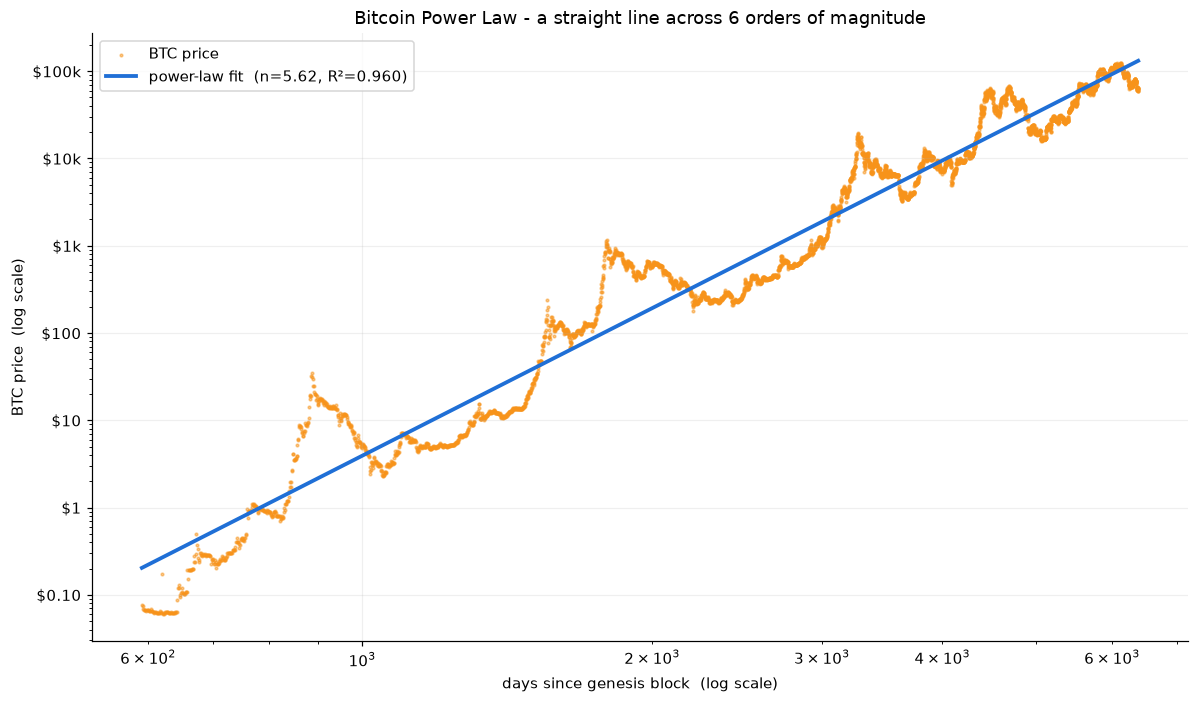

In [32]:
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(df["days"], df["Price"], s=3, c="#f7931a", alpha=0.5, label="BTC price")
xs = np.array([df["days"].min(), df["days"].max()])
ax.plot(xs, A * xs**n, c="#1f6fd6", lw=2.5, label=f"power-law fit  (n={n:.2f}, R²={r2:.3f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.yaxis.set_major_formatter(USD)
ax.set_xlabel("days since genesis block  (log scale)")
ax.set_ylabel("BTC price  (log scale)")
ax.set_title("Bitcoin Power Law - a straight line across 6 orders of magnitude")
ax.legend()
plt.tight_layout(); plt.show()

## 4. The fair-value corridor (the main chart)

Price never sits exactly on the line - it swings above (bull-market froth) and below (bear-market lows).
We draw a **corridor**: the *support* line (1st percentile of historical deviations = "floor")
and the *resistance* line (99th percentile = "expensive ceiling"). The model is projected forward to 2035.
**Today's** support, fair-value and resistance prices are shown in the **legend**; only today's price
is marked on the chart itself.

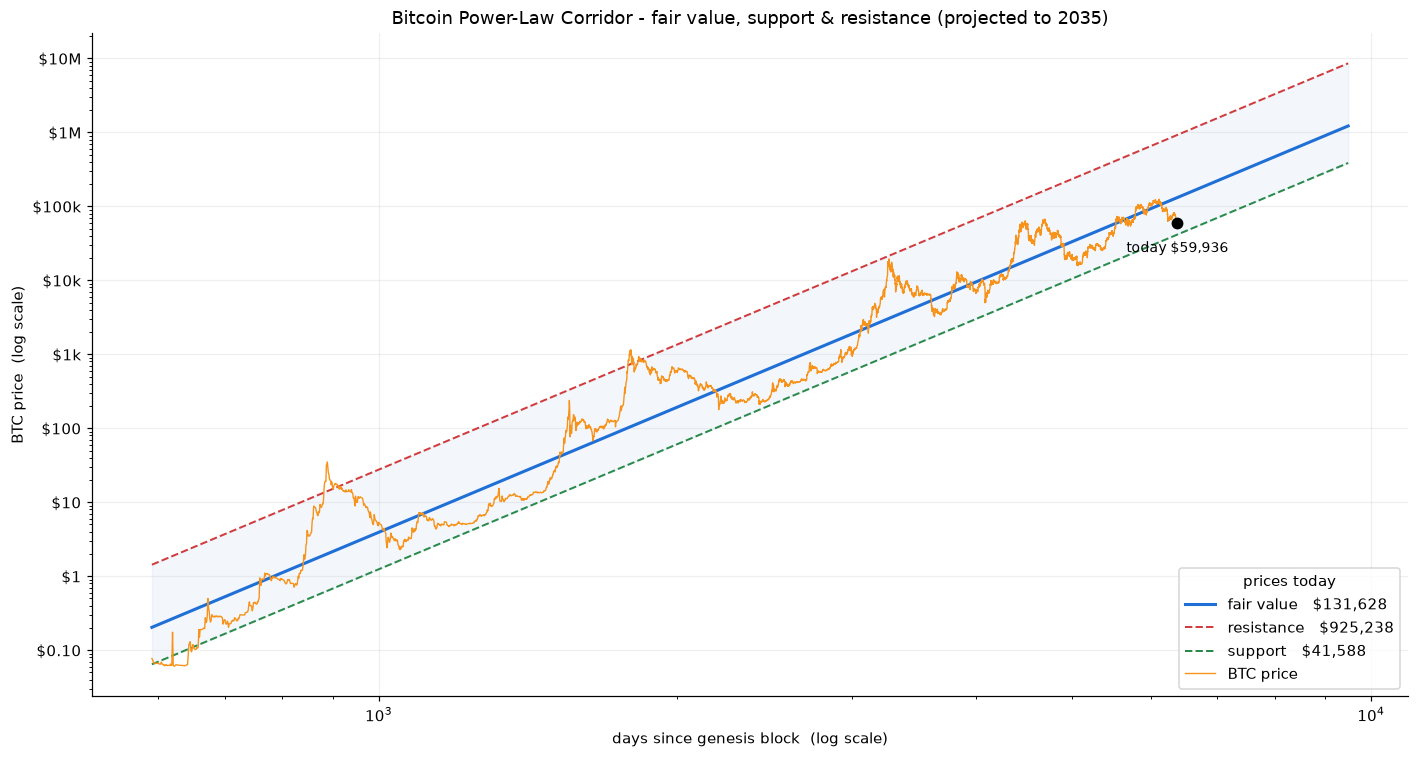

Today 2026-06-27:  support $41,588   fair $131,628   resistance $925,238


In [ ]:
resid = y - yhat
sd = resid.std()                                   # std of deviations (used by later sections)
support_mult    = 10 ** np.percentile(resid,  1)   # floor
resistance_mult = 10 ** np.percentile(resid, 99)   # expensive ceiling

future = pd.date_range(df.Date.min(), "2035-01-01", freq="7D")
fdays  = (future - GENESIS).days.values.astype(float)
fmid   = A * fdays**n

# today's corridor prices - shown in the legend
td      = float(df["days"].iloc[-1])
fv_now  = A * td**n
sup_now = fv_now * support_mult
res_now = fv_now * resistance_mult

fig, ax = plt.subplots(figsize=(13, 7))
ax.fill_between(fdays, fmid*support_mult, fmid*resistance_mult, color="#1f6fd6", alpha=0.05)
ax.plot(fdays, fmid,                 c="#1f6fd6", lw=2,            label=f"fair value   ${fv_now:,.0f}")
ax.plot(fdays, fmid*resistance_mult, c="#d23b3b", lw=1.3, ls="--", label=f"resistance   ${res_now:,.0f}")
ax.plot(fdays, fmid*support_mult,    c="#2a8a4a", lw=1.3, ls="--", label=f"support   ${sup_now:,.0f}")
ax.plot(df["days"], df.Price,        c="#f7931a", lw=0.9,          label="BTC price")

# only "today" is labelled on the chart itself
py = df.Price.iloc[-1]
ax.scatter([td], [py], c="black", zorder=6, s=45)
ax.annotate(f"today ${py:,.0f}", (td, py), fontsize=9, va="top", ha="center",
            xytext=(0, -12), textcoords="offset points")

ax.set_xscale("log"); ax.set_yscale("log"); ax.yaxis.set_major_formatter(USD)
ax.set_xlabel("days since genesis block  (log scale)"); ax.set_ylabel("BTC price  (log scale)")
ax.set_title("Bitcoin Power-Law Corridor - fair value, support & resistance (projected to 2035)")
ax.legend(loc="lower right", title="prices today")
plt.tight_layout(); plt.show()

## 5. Histogram - where has BTC actually spent its time?

This counts **how many days** Bitcoin traded at each distance from the power-law trend, measured in
**standard deviations (σ)**. Negative = below the trend, positive = above. If the
deviations were perfectly normal the bars would trace the blue bell curve. The black line marks **today**.

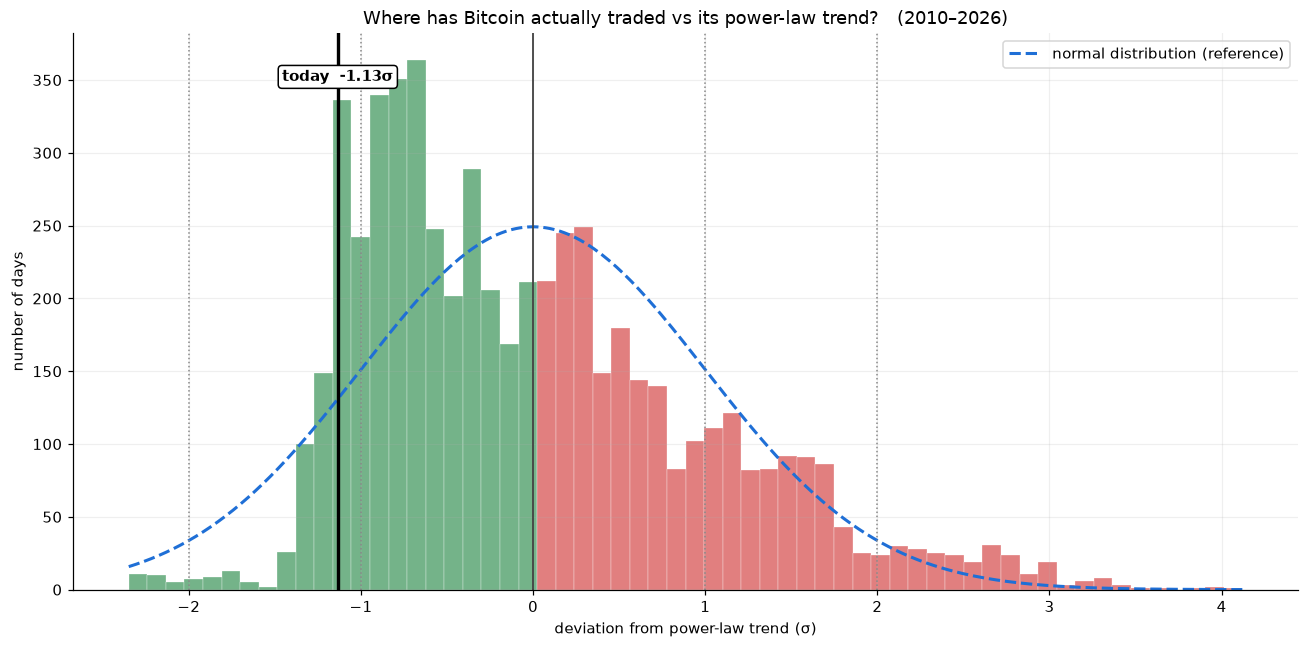

Total 5,794 days.  Median deviation: -0.20σ.
Days BELOW trend: 56%     ABOVE trend: 44%
Today: -1.13σ (BELOW trend)  =  BTC has been this low or lower only 8% of all days


In [34]:
z = (resid / sd).values                      # deviation from trend, in σ units
z_now = float(z[-1])

fig, ax = plt.subplots(figsize=(12, 6))
counts, bins, patches = ax.hist(z, bins=60, edgecolor="white", linewidth=0.3)
centers = (bins[:-1] + bins[1:]) / 2
for patch, c in zip(patches, centers):           # colour: green = below, red = above
    patch.set_facecolor("#2a8a4a" if c < 0 else "#d23b3b"); patch.set_alpha(0.65)

# normal curve for reference (same area as the histogram)
xs = np.linspace(z.min(), z.max(), 300)
binw = bins[1] - bins[0]
ax.plot(xs, len(z)*binw*np.exp(-xs**2/2)/np.sqrt(2*np.pi), c="#1f6fd6", lw=2, ls="--",
        label="normal distribution (reference)")

for s in (-2, -1, 1, 2):                          # σ guide lines
    ax.axvline(s, color="#888", ls=":", lw=1)
ax.axvline(0, color="#444", lw=1.2)               # the trend line
ax.axvline(z_now, color="black", lw=2.2)
ax.annotate(f"today  {z_now:+.2f}σ", (z_now, counts.max()*0.96),
            ha="center", fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black"))

ax.set_xlabel("deviation from power-law trend (σ)")
ax.set_ylabel("number of days")
ax.set_title("Where has Bitcoin actually traded vs its power-law trend?   (2010–2026)")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

below = np.mean(z < 0) * 100
print(f"Total {len(z):,} days.  Median deviation: {np.median(z):+.2f}σ.")
print(f"Days BELOW trend: {below:.0f}%     ABOVE trend: {100-below:.0f}%")
pct_lower    = np.mean(z <= z_now) * 100      # share of days at least this low
pct_higher   = np.mean(z >= z_now) * 100      # share of days at least this high
if z_now < 0:
    print(f"Today: {z_now:+.2f}σ (BELOW trend)  =  BTC has been this low or lower only {pct_lower:.0f}% of all days")
else:
    print(f"Today: {z_now:+.2f}σ (ABOVE trend)  =  BTC has been this high or higher only {pct_higher:.0f}% of all days")

## 5b. Residuals (σ) oscillator - above & below the trend over time

The histogram above squashes time away. Here the same σ-deviation is plotted **chronologically**: 
every day Bitcoin closed *above* its power-law trend is shaded red, every day *below* is shaded green.

/tmp/ipykernel_4723/3137849611.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


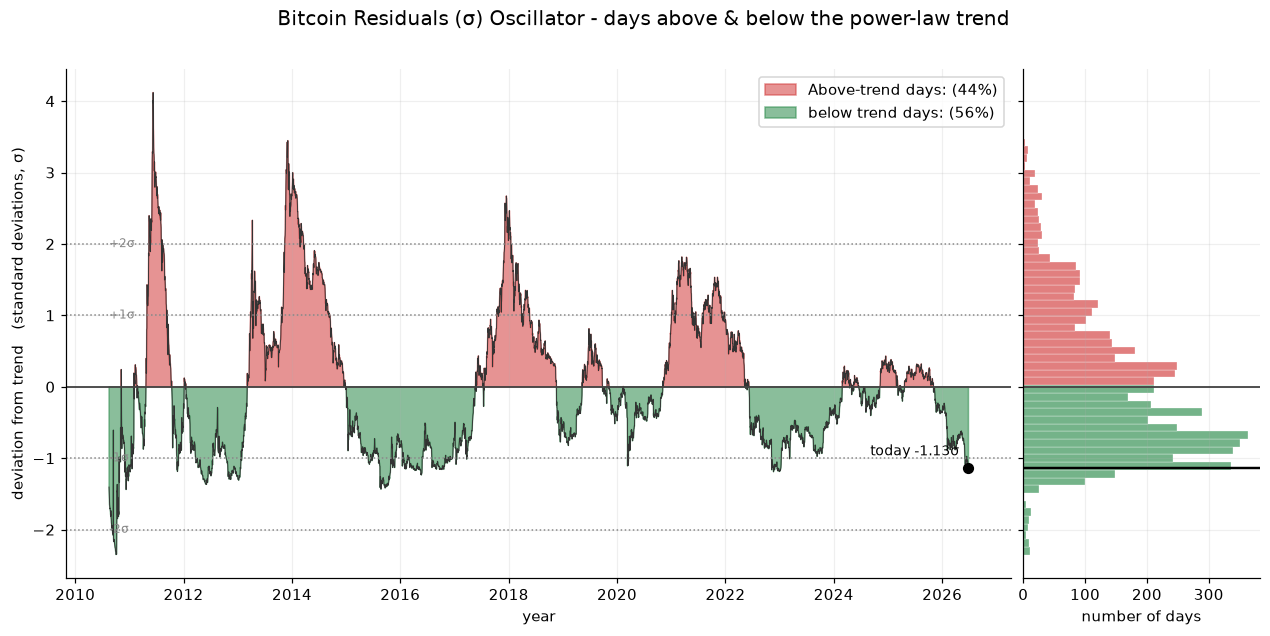

In [35]:
# Residuals (sigma) oscillator over time, with the matching distribution on the right
zt = pd.Series(z, index=df["Date"])
above_days = int(np.sum(z > 0)); below_days = int(np.sum(z < 0))

fig, (ax, axh) = plt.subplots(1, 2, figsize=(14, 6), sharey=True,
                              gridspec_kw=dict(width_ratios=[4, 1], wspace=0.02))

# --- left: oscillator through time ---
ax.fill_between(zt.index, zt.values, 0, where=zt.values >= 0,
                color="#d23b3b", alpha=0.55, interpolate=True, label=f"Above-trend days: ({above_days/len(z)*100:.0f}%)"
)
ax.fill_between(zt.index, zt.values, 0, where=zt.values < 0,
                color="#2a8a4a", alpha=0.55, interpolate=True, label=f"below trend days: ({below_days/len(z)*100:.0f}%)")
ax.plot(zt.index, zt.values, color="#333", lw=0.6)

ax.axhline(0, color="#444", lw=1.2)               # the power-law trend
for s in (-2, -1, 1, 2):                           # sigma guide lines
    ax.axhline(s, color="#888", ls=":", lw=1)
    ax.annotate(f"{s:+d}σ", (zt.index[0], s), fontsize=8, color="#888", va="center")

ax.scatter([zt.index[-1]], [z_now], c="black", zorder=6, s=40)
ax.annotate(f"today {z_now:+.2f}σ", (zt.index[-1], z_now), fontsize=9,
            ha="right", va="bottom", xytext=(-6, 6), textcoords="offset points")

ax.set_xlabel("year")
ax.set_ylabel("deviation from trend   (standard deviations, σ)")
ax.legend(loc="upper right")

# --- right: same sigma distribution, rotated to share the y-axis (long upward tail) ---
counts, bins, patches = axh.hist(z, bins=60, orientation="horizontal",
                                 edgecolor="white", linewidth=0.3)
centers = (bins[:-1] + bins[1:]) / 2
for patch, c in zip(patches, centers):            # green = below, red = above
    patch.set_facecolor("#2a8a4a" if c < 0 else "#d23b3b"); patch.set_alpha(0.65)

ys = np.linspace(z.min(), z.max(), 300)           # normal curve for reference
binw = bins[1] - bins[0]

axh.axhline(0, color="#444", lw=1.2)
axh.axhline(z_now, color="black", lw=1.6)
axh.set_xlabel("number of days")
axh.tick_params(labelleft=False)

fig.suptitle("Bitcoin Residuals (σ) Oscillator - days above & below the power-law trend",
             y=0.97, fontsize=13)
plt.tight_layout(); plt.show()

## 6. Asymmetric 67% & 95% percentile bands

A widely-cited presentation of this model uses the same power law (an example published fit:
`a = 1.7e-17`, `b = 5.76`) but draws **asymmetric percentile bands** instead of symmetric σ:

- a **67% band** = 16.5th–83.5th percentile of deviations (≈1σ, blue)
- a **95% band** = 2.5th–97.5th percentile (≈2σ, red)

Because BTC's deviations are **right-skewed** (see the histogram in §5), these bands are wider above the
trend than below - more honest than assuming a bell curve. It also notes a neat rule: since
`price ∝ days^b`, the trend price **doubles every time Bitcoin's age grows ~13%**.

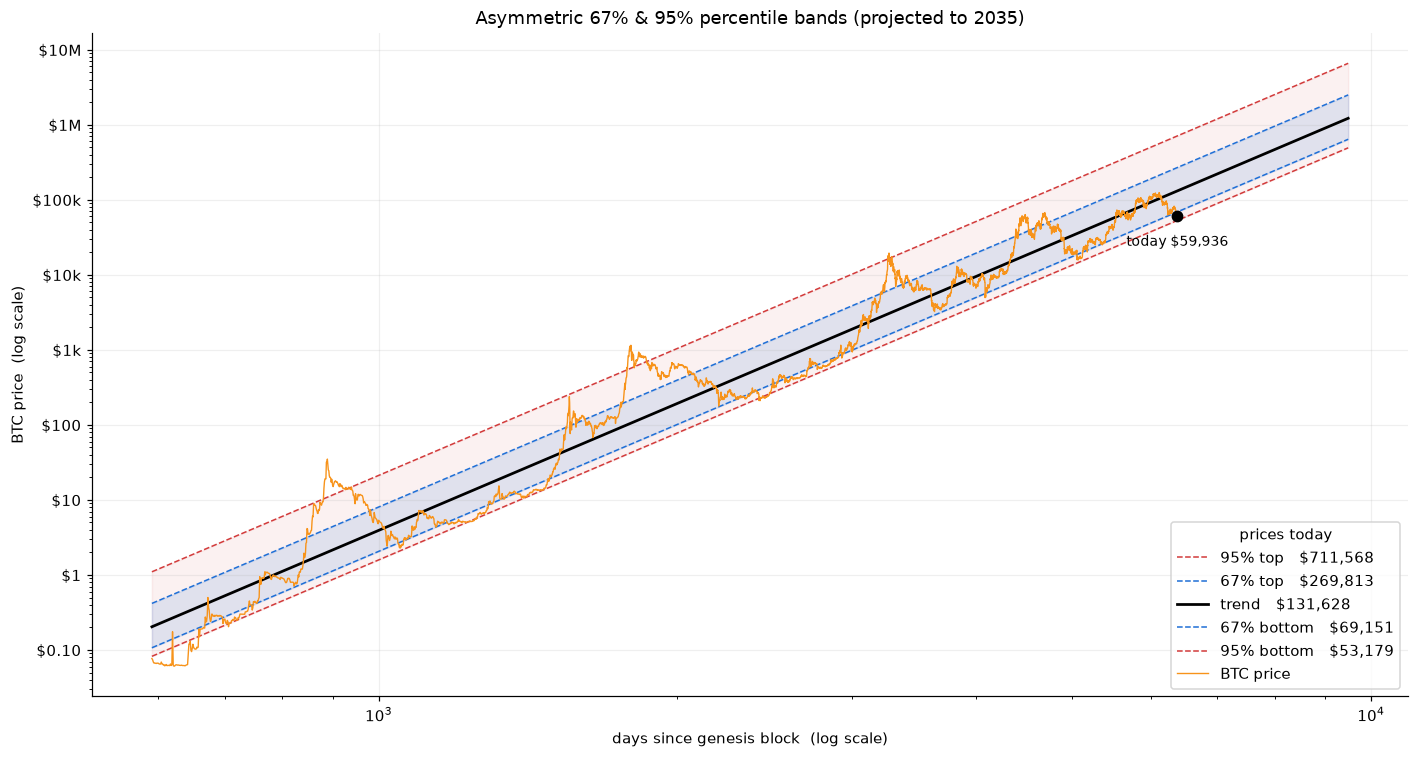

Asymmetry: upper 95% band is +441% above trend, lower 95% band is -60% below  (skewed, not symmetric).
Doubling rule: +13.1% more days doubles the trend price -> at 6,384 days old that is ~838 more days (2.3 yr).
Today BTC sits at the 8th percentile of its historical trend deviation.


In [36]:
# asymmetric percentile bands
pcts  = [2.5, 16.5, 83.5, 97.5]
mult  = {p: 10 ** np.percentile(resid, p) for p in pcts}

fig, ax = plt.subplots(figsize=(13, 7))
ax.fill_between(fdays, fmid*mult[2.5],  fmid*mult[97.5], color="#d23b3b", alpha=0.07)
ax.fill_between(fdays, fmid*mult[16.5], fmid*mult[83.5], color="#1f6fd6", alpha=0.12)
ax.plot(fdays, fmid*mult[97.5], c="#d23b3b", lw=1, ls="--", label=f"95% top   ${fv_now*mult[97.5]:,.0f}")
ax.plot(fdays, fmid*mult[83.5], c="#1f6fd6", lw=1, ls="--", label=f"67% top   ${fv_now*mult[83.5]:,.0f}")
ax.plot(fdays, fmid,            c="black",   lw=1.8,        label=f"trend   ${fv_now:,.0f}")
ax.plot(fdays, fmid*mult[16.5], c="#1f6fd6", lw=1, ls="--", label=f"67% bottom   ${fv_now*mult[16.5]:,.0f}")
ax.plot(fdays, fmid*mult[2.5],  c="#d23b3b", lw=1, ls="--", label=f"95% bottom   ${fv_now*mult[2.5]:,.0f}")
ax.plot(df["days"], df.Price,       c="#f7931a", lw=0.9,        label="BTC price")

px, py = df["days"].iloc[-1], df.Price.iloc[-1]
ax.scatter([px], [py], c="black", zorder=6, s=45)
ax.annotate(f"today ${py:,.0f}", (px, py), fontsize=9, va="top", ha="center",
            xytext=(0, -12), textcoords="offset points")
ax.set_xscale("log"); ax.set_yscale("log"); ax.yaxis.set_major_formatter(USD)
ax.set_xlabel("days since genesis block  (log scale)"); ax.set_ylabel("BTC price  (log scale)")
ax.set_title("Asymmetric 67% & 95% percentile bands (projected to 2035)")
ax.legend(loc="lower right", title="prices today"); plt.tight_layout(); plt.show()

grow = 2**(1/n) - 1                          # % more days for the trend to double
days_now = float(df["days"].iloc[-1])
pct_today = np.mean(resid <= resid.iloc[-1]) * 100
print(f"Asymmetry: upper 95% band is +{(mult[97.5]-1)*100:.0f}% above trend, "
      f"lower 95% band is {(mult[2.5]-1)*100:.0f}% below  (skewed, not symmetric).")
print(f"Doubling rule: +{grow*100:.1f}% more days doubles the trend price -> "
      f"at {days_now:,.0f} days old that is ~{days_now*grow:,.0f} more days ({days_now*grow/365:.1f} yr).")
print(f"Today BTC sits at the {pct_today:.0f}th percentile of its historical trend deviation.")

## 7. Fitting the asymmetric distribution properly (skew-normal bands)

§5 showed the deviations are **right-skewed**, so a symmetric bell curve mis-states the tails. Here we
fit a **skew-normal** distribution to the deviations and read the **2.5th and 97.5th percentiles**
straight from the fitted curve - a smooth, parametric estimate of the band edges that respects the
asymmetry. Left panel: the fit (skew-normal vs a symmetric normal). Right panel: the resulting
2.5% / 97.5% bands around the power-law trend.

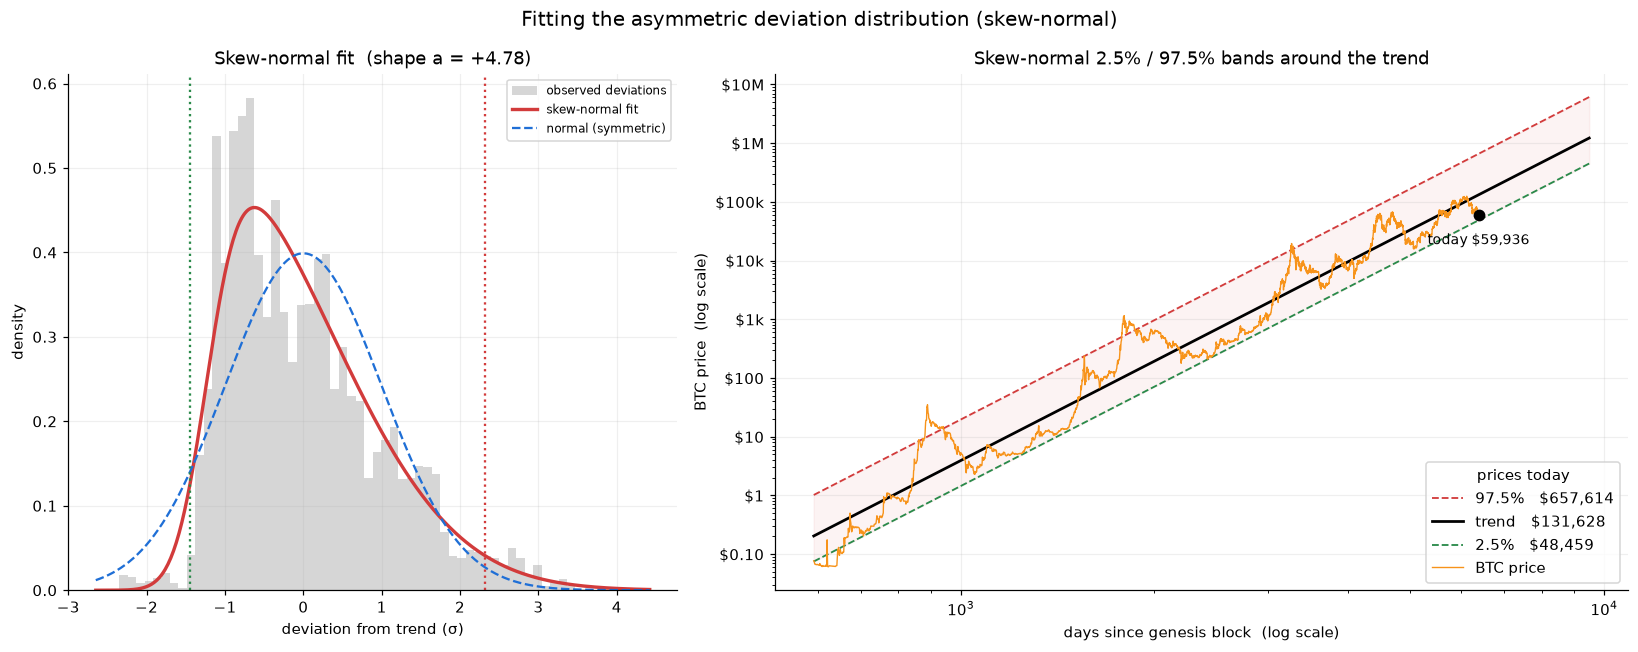

skew-normal shape a = +4.78  (positive = right-skewed, as observed)
97.5% band:  fitted x5.00 ($657,614)   empirical x5.41
 2.5% band:  fitted x0.37 ($48,459)   empirical x0.40
goodness of fit (KS, smaller=better):  skew-normal 0.045   vs   normal 0.086


In [37]:
from scipy import stats

z = resid.values / sd                                  # deviations in σ units (all history)
a_sk, loc_sk, sc_sk = stats.skewnorm.fit(z)            # fit the skewed distribution
z_lo, z_hi = stats.skewnorm.ppf([0.025, 0.975], a_sk, loc_sk, sc_sk)
m_lo, m_hi = 10**(z_lo*sd), 10**(z_hi*sd)              # -> price multipliers
e_lo, e_hi = np.percentile(z, 2.5), np.percentile(z, 97.5)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.4]})

xs = np.linspace(z.min()-0.3, z.max()+0.3, 400)
axL.hist(z, bins=60, density=True, color="#bbb", alpha=0.6, label="observed deviations")
axL.plot(xs, stats.skewnorm.pdf(xs, a_sk, loc_sk, sc_sk), c="#d23b3b", lw=2.2, label="skew-normal fit")
axL.plot(xs, stats.norm.pdf(xs, z.mean(), z.std()),       c="#1f6fd6", lw=1.5, ls="--", label="normal (symmetric)")
axL.axvline(z_lo, color="#2a8a4a", lw=1.5, ls=":"); axL.axvline(z_hi, color="#d23b3b", lw=1.5, ls=":")
axL.set_xlabel("deviation from trend (σ)"); axL.set_ylabel("density")
axL.set_title(f"Skew-normal fit  (shape a = {a_sk:+.2f})"); axL.legend(fontsize=8)

axR.fill_between(fdays, fmid*m_lo, fmid*m_hi, color="#d23b3b", alpha=0.06)
axR.plot(fdays, fmid*m_hi, c="#d23b3b", lw=1.2, ls="--", label=f"97.5%   ${fv_now*m_hi:,.0f}")
axR.plot(fdays, fmid,      c="black",   lw=1.8,         label=f"trend   ${fv_now:,.0f}")
axR.plot(fdays, fmid*m_lo, c="#2a8a4a", lw=1.2, ls="--", label=f"2.5%   ${fv_now*m_lo:,.0f}")
axR.plot(df["days"], df.Price, c="#f7931a", lw=0.9, label="BTC price")
px, py = df["days"].iloc[-1], df.Price.iloc[-1]
axR.scatter([px], [py], c="black", zorder=6, s=45)
axR.annotate(f"today ${py:,.0f}", (px, py), fontsize=9, va="top", ha="center",
             xytext=(0, -12), textcoords="offset points")
axR.set_xscale("log"); axR.set_yscale("log"); axR.yaxis.set_major_formatter(USD)
axR.set_xlabel("days since genesis block  (log scale)"); axR.set_ylabel("BTC price  (log scale)")
axR.set_title("Skew-normal 2.5% / 97.5% bands around the trend"); axR.legend(loc="lower right", title="prices today")
fig.suptitle("Fitting the asymmetric deviation distribution (skew-normal)", fontsize=13)
plt.tight_layout(); plt.show()

print(f"skew-normal shape a = {a_sk:+.2f}  (positive = right-skewed, as observed)")
print(f"97.5% band:  fitted x{m_hi:.2f} (${fv_now*m_hi:,.0f})   empirical x{10**(e_hi*sd):.2f}")
print(f" 2.5% band:  fitted x{m_lo:.2f} (${fv_now*m_lo:,.0f})   empirical x{10**(e_lo*sd):.2f}")
ks_s = stats.kstest(z, 'skewnorm', args=(a_sk, loc_sk, sc_sk)).statistic
ks_n = stats.kstest(z, 'norm',     args=(z.mean(), z.std())).statistic
print(f"goodness of fit (KS, smaller=better):  skew-normal {ks_s:.3f}   vs   normal {ks_n:.3f}")

**Close-up of the last 12 months.** The same skew-normal 2.5% / 97.5% bands and trend, zoomed
into recent price action so you can see exactly where BTC sits in the band right now.

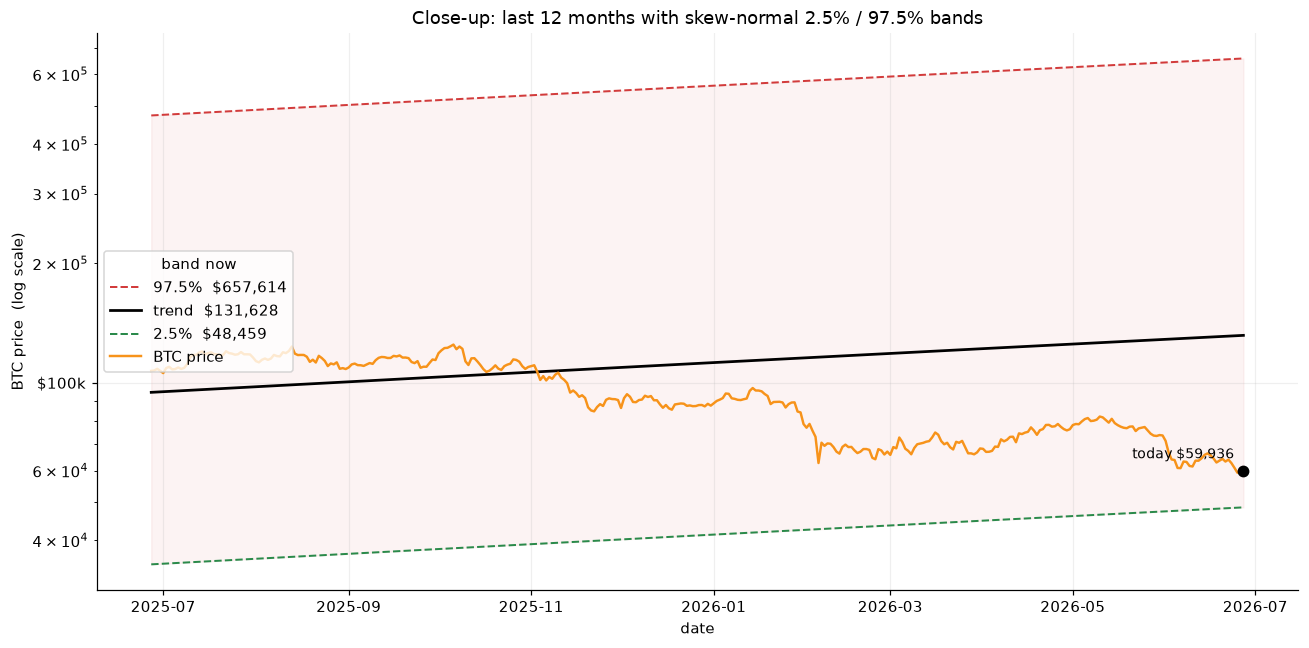

12-month range: $59,269 - $124,753   today $59,936 vs trend $131,628 (0.46x)


In [38]:
recent = df[df["Date"] >= df["Date"].max() - pd.Timedelta(days=365)].copy()
rtrend = A * recent["days"].values.astype(float)**n

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(recent.Date, rtrend*m_lo, rtrend*m_hi, color="#d23b3b", alpha=0.06)
ax.plot(recent.Date, rtrend*m_hi,  c="#d23b3b", lw=1.3, ls="--", label=f"97.5%  ${rtrend[-1]*m_hi:,.0f}")
ax.plot(recent.Date, rtrend,       c="black",   lw=1.8,         label=f"trend  ${rtrend[-1]:,.0f}")
ax.plot(recent.Date, rtrend*m_lo,  c="#2a8a4a", lw=1.3, ls="--", label=f"2.5%  ${rtrend[-1]*m_lo:,.0f}")
ax.plot(recent.Date, recent.Price, c="#f7931a", lw=1.6,         label="BTC price")
px, py = recent.Date.iloc[-1], recent.Price.iloc[-1]
ax.scatter([px], [py], c="black", zorder=6, s=45)
ax.annotate(f"today ${py:,.0f}", (px, py), fontsize=9, va="bottom", ha="right",
            xytext=(-6, 6), textcoords="offset points")
ax.set_yscale("log"); ax.yaxis.set_major_formatter(USD)
ax.set_xlabel("date"); ax.set_ylabel("BTC price  (log scale)")
ax.set_title("Close-up: last 12 months with skew-normal 2.5% / 97.5% bands")
ax.legend(loc="best", title="band now")
plt.tight_layout(); plt.show()

print(f"12-month range: ${recent.Price.min():,.0f} - ${recent.Price.max():,.0f}   "
      f"today ${py:,.0f} vs trend ${rtrend[-1]:,.0f} ({py/rtrend[-1]:.2f}x)")

## 8. Risk metric - how expensive is BTC right now?

For **each day** we rank the price's deviation from trend against every deviation seen **up to that day**
(point-in-time, no hindsight) and squash it to a single **0-1** number: **0 = the lowest BTC has ever
been vs trend (buy)**, **1 = the highest (sell)**. The top panel colours the price by risk; the bottom
panel is the oscillator, with buy (green) and sell (red) zones shaded.

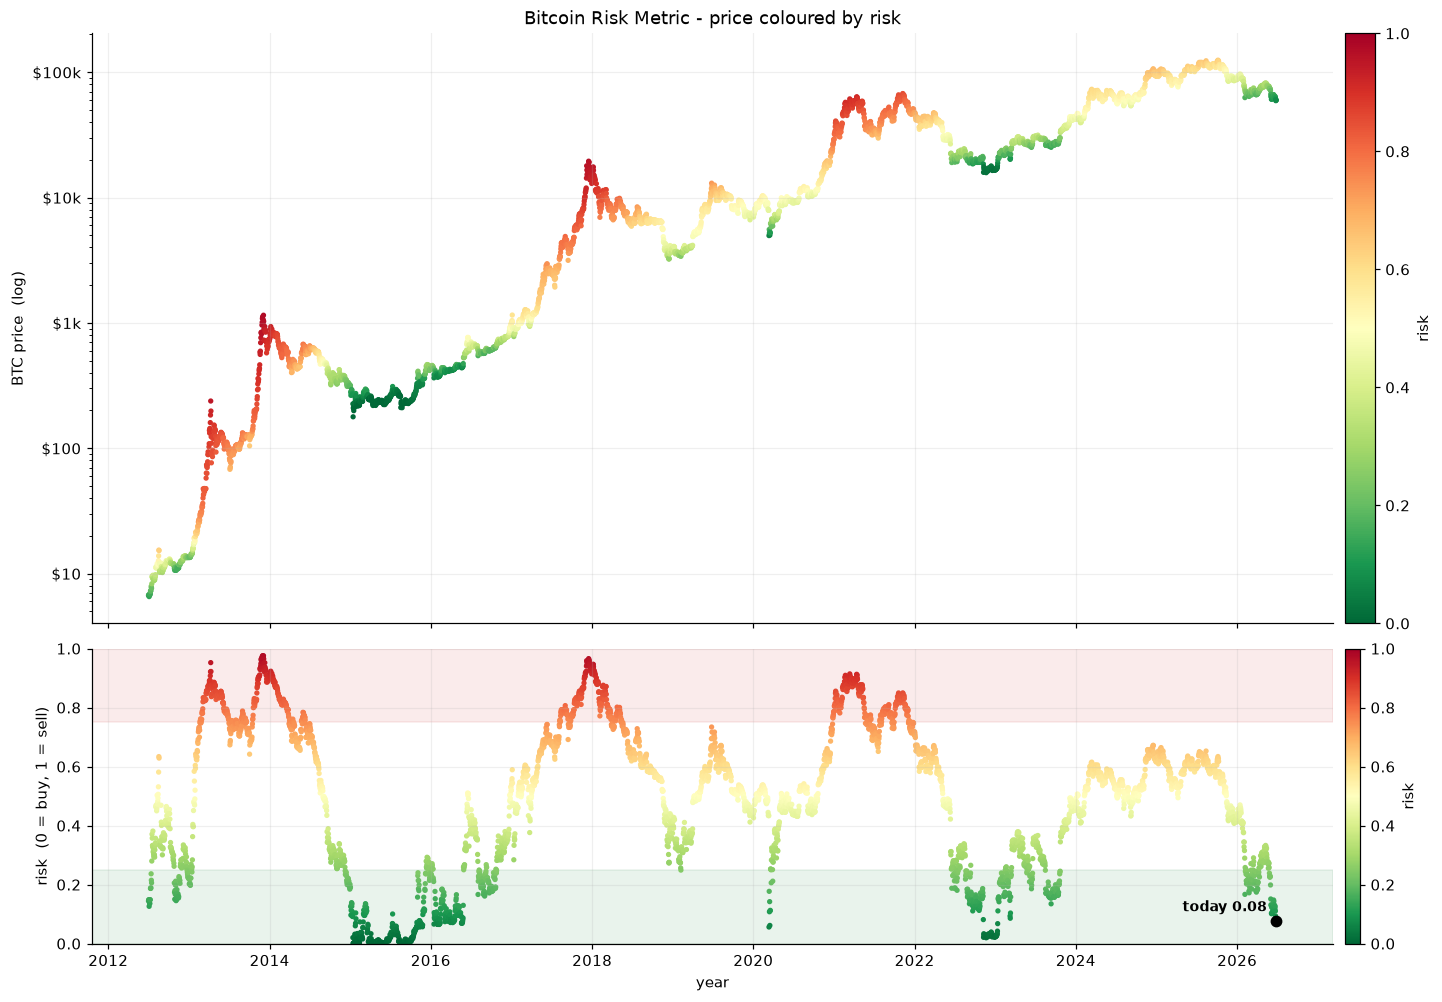

In [39]:
logd = np.log10(df["days"].values)
logp = np.log10(df["Price"].values)
start = int(np.argmax(df["Date"].values >= np.datetime64("2012-07-01")))

risk = np.full(len(df), np.nan)
for i in range(start, len(df)):                          # expanding window, daily
    ni, bi = np.polyfit(logd[:i+1], logp[:i+1], 1)
    r = logp[:i+1] - (ni*logd[:i+1] + bi)
    risk[i] = np.mean(r <= r[-1])                        # percentile rank of today, 0..1
valid = ~np.isnan(risk)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]}, constrained_layout=True)
sc1 = ax1.scatter(df.Date[valid], df.Price[valid], c=risk[valid], cmap="RdYlGn_r", s=6, vmin=0, vmax=1)
ax1.set_yscale("log"); ax1.yaxis.set_major_formatter(USD); ax1.set_ylabel("BTC price  (log)")
ax1.set_title("Bitcoin Risk Metric - price coloured by risk")
fig.colorbar(sc1, ax=ax1, label="risk", pad=0.01)

ax2.axhspan(0.0, 0.25, color="#2a8a4a", alpha=0.10)
ax2.axhspan(0.75, 1.0, color="#d23b3b", alpha=0.10)
sc2 = ax2.scatter(df.Date[valid], risk[valid], c=risk[valid], cmap="RdYlGn_r", s=6, vmin=0, vmax=1)
ax2.scatter([df.Date.iloc[-1]], [risk[-1]], c="black", s=45, zorder=6)
ax2.annotate(f"today {risk[-1]:.2f}", (df.Date.iloc[-1], risk[-1]), fontsize=9, fontweight="bold",
             ha="right", va="bottom", xytext=(-6, 4), textcoords="offset points")
ax2.set_ylim(0, 1); ax2.set_ylabel("risk  (0 = buy, 1 = sell)"); ax2.set_xlabel("year")
fig.colorbar(sc2, ax=ax2, label="risk", pad=0.01)
plt.show()

zone = "BUY zone" if risk[-1] < 0.25 else "SELL zone" if risk[-1] > 0.75 else "neutral"

## 9. Smoothed risk metric

The daily risk wiggles a lot. A rolling average smooths it into a cleaner cycle signal with fewer false
flips between zones. Edit `SMOOTH` (days) to taste.

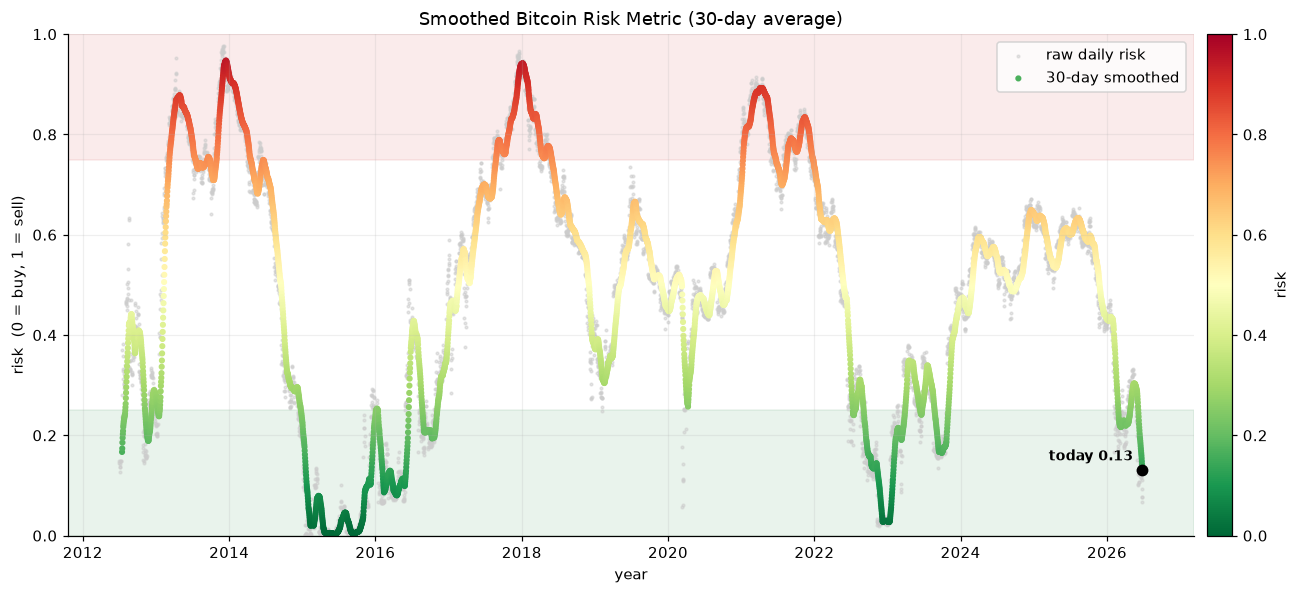

In [40]:
SMOOTH = 30      # rolling-average window in days

risk_s = pd.Series(risk).rolling(SMOOTH, min_periods=SMOOTH//2).mean().values
v = ~np.isnan(risk_s)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhspan(0.0, 0.25, color="#2a8a4a", alpha=0.10)
ax.axhspan(0.75, 1.0, color="#d23b3b", alpha=0.10)
ax.scatter(df.Date[valid], risk[valid], c="#cccccc", s=3, alpha=0.5, label="raw daily risk")
sc = ax.scatter(df.Date[v], risk_s[v], c=risk_s[v], cmap="RdYlGn_r", s=9, vmin=0, vmax=1,
                label=f"{SMOOTH}-day smoothed")
ax.scatter([df.Date.iloc[-1]], [risk_s[-1]], c="black", s=45, zorder=6)
ax.annotate(f"today {risk_s[-1]:.2f}", (df.Date.iloc[-1], risk_s[-1]), fontsize=9, fontweight="bold",
            ha="right", va="bottom", xytext=(-6, 4), textcoords="offset points")
ax.set_ylim(0, 1); ax.set_ylabel("risk  (0 = buy, 1 = sell)"); ax.set_xlabel("year")
ax.set_title(f"Smoothed Bitcoin Risk Metric ({SMOOTH}-day average)")
ax.legend(loc="upper right"); fig.colorbar(sc, ax=ax, label="risk", pad=0.01)
plt.tight_layout(); plt.show()

zone = "BUY zone" if risk_s[-1] < 0.25 else "SELL zone" if risk_s[-1] > 0.75 else "neutral"